<h1><b><font color=#6799FF>A. 사진에 있는 글자 인식하기</h1></b></font color>
<font size=2>저장된 사진에 적혀있는 글자를 올바르게 인식하는지 간단하게 확인해보고자 한다. 

<h5><b>1. 필요 라이브러리 설치하기

In [ ]:
!pip install pytesseract
!pip install matplotlib

<h5><b>2. OCR에 사용할 사진 확인하기 

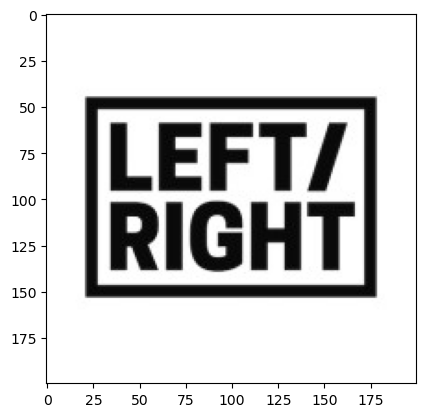

In [18]:
import pytesseract
import cv2
import matplotlib.pyplot as plt

pytesseract.pytesseract.tesseract_cmd = "C:/Program Files/Tesseract-OCR/tesseract.exe"

img = cv2.imread("C:/Users/jjang/Desktop/leftRight_3.png")

plt.imshow(img)

<h5><b>3. 사진의 글자 추출 및 인식 결과 확인하기

In [21]:
img2char = pytesseract.image_to_string(img, lang='eng')

In [32]:
print("추출된 텍스트 : ")
print(img2char)

추출된 텍스트 : 
LEFT/
RIG



<h1><b><font color=#6799FF>B. 실시간으로 OCR 구동하기</h1></b></font color>
<font size=2>웹캠을 통해 실시간으로 OCR이 잘 되는지 확인하고자 한다. 
<br>인식된 글자 결과값이 결과창 상단에 잘 출력되는지 확인한다.

In [14]:
import numpy as np
import cv2
from PIL import Image
import pytesseract

cap = cv2.VideoCapture(0)

while(True):
    ret, frame = cap.read()
    #cv2.putText(frame,"python",(100,100), font, 5,(255,255,255),2,cv2.LINE_AA)

    # 영상에 이미지를 출력하는 부분.
    img = Image.fromarray(frame) # frame으로 넣어도 된다.
    pytesseract.pytesseract.tesseract_cmd = "C:/Program Files/Tesseract-OCR/tesseract.exe"
    txt = pytesseract.image_to_string(img)
    # 한글     : image_to_string(img, lang='kor')
    # 여러 언어 :image_to_string(img, lang='kor+eng')
    
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(frame,txt,(10,30), font, 1,(255,255,255),2,cv2.LINE_AA)

    # Display the resulting frame
    cv2.imshow('frame', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    
cap.release()
cv2.destroyAllWindows()


<h1><b><font color=#6799FF>C. 실시간 OCR 구동 및 인식된 글자에 바운딩 박스 생성하기</h1></b></font color>
<font size=2>웹캠을 통해 실시간으로 OCR이 잘 되는지 확인하고자 한다. 
<br>인식된 글자마다 박스가 생성되고 결과값이 결과창 상단에 잘 출력되는지 확인한다.

In [15]:
import cv2
import numpy as np 

font_scale = 1.5
font = cv2.FONT_HERSHEY_PLAIN

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise IOError("Cannot open the Webcam")

cnt = 0 

while True:
    ret, frame = cap.read()
    cnt = cnt + 1
    
    if ((cnt % 20)==0):
        imgH, imgW, _ = frame.shape
        
        x1, y1, w1, h1 = 0, 0, imgH, imgW
        imgchar = pytesseract.image_to_string(frame)
        imgboxes = pytesseract.image_to_boxes(frame)
        
        for boxes in imgboxes.splitlines():
            boxes = boxes.split(" ")
            x, y, w, h = int(boxes[1]), int(boxes[2]), int(boxes[3]), int(boxes[4])
            cv2.rectangle(frame, (x, imgH-y), (w, imgH-h), (0,0,255), 3)
            
            cv2.putText(frame, imgchar, (x1+int(w1/50), y1+int(h1/50)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)
            
            font = cv2.FONT_HERSHEY_SIMPLEX
            
            cv2.imshow('Test OCR', frame)
            
            if cv2.waitKey(2) & 0xFF == ord('q'):
                break

cap.release()
cv2.destroyAllWindows()
            
            

KeyboardInterrupt: 

<h1><b><font color=#6799FF>D. 웹캠을 통해 프레임 캡쳐하기 </h1></b></font color>
<font size=2>웹캠을 통해 캡쳐된 사진을 활용하기 위한 코드이다. 

In [2]:
import cv2 
import matplotlib.pyplot as plt

In [3]:
# 카메라 캡처를 위한 VideoCapture 객체 생성
cap = cv2.VideoCapture(0)

# 캡처된 이미지를 저장할 파일명
filename = 'card.jpg'

while True:
    # 프레임 읽기
    ret, frame = cap.read()
    
    # 프레임을 화면에 출력
    cv2.imshow('Camera', frame)
    
    # 엔터 키를 누르면 캡처된 이미지 저장 후 루프 종료
    if cv2.waitKey(1) == 13:
        cv2.imwrite(filename, frame)
        print("캡처된 이미지가 저장되었습니다.")
        break

# VideoCapture 객체 해제
cap.release()
# 모든 OpenCV 윈도우 닫기
cv2.destroyAllWindows()

캡처된 이미지가 저장되었습니다.


<h1><b><font color=#6799FF>E. 영수증 OCR 및 총액 추출하기</h1></b></font color>
<font size=2>1. 원근법을 활용하여 스캔한 영수증 버전 가져오기 
<br>2. OCR을 적용하여 이미지 내의 모든 텍스트 찾기 
<br>3. 인식된 텍스트 중 가장 많은 숫자 찾기 


<h5><b>1. 영수증 사진 확인하기 

In [29]:
import cv2
import matplotlib.pyplot as plt

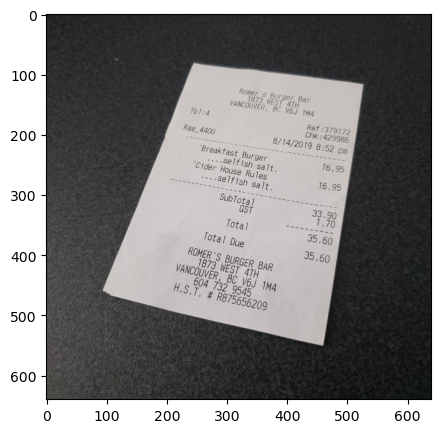

In [30]:
file_name = "receipt.jpg"
image = cv2.imread(file_name) 

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

<h5><b>2. 영수증 사진 전처리하기 

In [31]:
import cv2
import numpy as np

def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect
    
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))
    
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))
    
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")
    
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
    return warped

def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 75, 200)
    
    cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c = max(cnts, key=cv2.contourArea)
    screenCnt = cv2.approxPolyDP(c, 0.02 * cv2.arcLength(c, True), True)
    
    return four_point_transform(image, screenCnt.reshape(4, 2))

def apply_threshold(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return thresh

# 영수증 이미지 경로
image_path = 'receipt.jpg'

# 이미지 불러오기
image = cv2.imread(image_path)

# 전처리
processed_image = preprocess_image(image)

# 임계값 적용
thresholded_image = apply_threshold(processed_image)


In [32]:
# 결과물 저장 
cv2.imwrite('processed_receipt.jpg', processed_image)
cv2.imwrite('thresholded_receipt.jpg', thresholded_image)

# 결과 출력
cv2.imshow("Original Image", image)
cv2.imshow("Processed Image", processed_image)
cv2.imshow("Thresholded Image", thresholded_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

<h5><b>3. 영수증 OCR 결과 확인하기

In [6]:
import cv2
import numpy as np
import pytesseract

pytesseract.pytesseract.tesseract_cmd = "C:/Program Files/Tesseract-OCR/tesseract.exe"

# OCR 수행
result = cv2.imread('thresholded_receipt.jpg')

gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)

text = pytesseract.image_to_string(gray)

# 결과 출력
print("Text from processed image:")
print(text)



Text from processed image:
Romer’ s. Burger Bar
1873 WEST 4TH
VANCOUVER, BF VBJ 1M4

Tohs4 Ref :3791/2

Chk : 429986

Rae_4400 8/14/2019 8:52 pm

‘Breakfast Burger 16.95
selfish salt,

“Cider House Rules 16.95

selfish salt.

SubTotal
GST

Total
Total Que 35.60
ROWER'S BURGER BAR
1873 WEST 41H
VANCOUVER, BC ¥5J 1M4

H.S.T. # R875656209



<h5><b>4. 영수증의 총액 추출하기 

In [33]:
import re

In [34]:
def find_amounts(text):
    amounts = re.findall(r'\d+\.\d{2}\b', text)
    floats = [float(amount) for amount in amounts]
    unique = list(dict.fromkeys(floats))
    return unique

In [35]:
amounts = find_amounts(text)
amounts

[16.95, 35.6]

In [36]:
max(amounts)

35.6